# 10 &middot; Resolution and Cost: the Accuracy/Speed Trade-off

Refining the mesh improves accuracy but makes every solve more expensive. We
measure both on a cantilever sagging under gravity:

* **cost**: Newton-solve time vs. vertex count (10 resolutions),
* **accuracy**: tip deflection converging to a very fine reference,
* the punchline: a super-fine mesh is accurate but **too slow to iterate on.**

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import simkit
import simkit.energies as energies
from simkit.solvers import newton_solver
import utils
os.makedirs("media", exist_ok=True)

## A timed static solve at any resolution

Soft enough (\(E = 800\)) that the sag is large and obvious. `gravity_scale`
lets us ramp gravity for the animation.

In [2]:
import time

def solve_beam(nx, ny, gravity_scale=1.0, iters=30):
    X, T = utils.triangulated_grid(nx, ny, width=2.0, height=0.3)
    n = X.shape[0]
    J, vol = simkit.deformation_jacobian(X, T), simkit.volume(X, T)
    f_g = (gravity_scale * simkit.gravity_force(X, T, a=-9.8, rho=1.0)).reshape(-1, 1)
    mu, lam = simkit.ympr_to_lame(800.0, 0.4)         # soft -> visible sag
    mu  = np.full((len(T), 1), mu)
    lam = np.full((len(T), 1), lam)
    pin = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
    Q_pin, b_pin = simkit.dirichlet_penalty(pin, X[pin], n, 1e7)

    def energy(x):
        xn, xc = x.reshape(-1, 2), x.reshape(-1, 1)
        E_elastic = energies.macklin_mueller_neo_hookean_energy_x(xn, J, mu, lam, vol)
        E_pin     = 0.5 * (xc.T @ (Q_pin @ xc))[0, 0] + (b_pin.T @ xc)[0, 0]
        E_gravity = -(f_g.T @ xc)[0, 0]
        E_total   = E_elastic + E_pin + E_gravity
        return E_total
    def gradient(x):
        xn, xc = x.reshape(-1, 2), x.reshape(-1, 1)
        g_elastic = energies.macklin_mueller_neo_hookean_gradient_x(xn, J, mu, lam, vol)
        g_pin     = Q_pin @ xc + b_pin
        g_gravity = -f_g
        g_total   = g_elastic + g_pin + g_gravity
        return g_total
    def hessian(x):
        xn = x.reshape(-1, 2)
        H_elastic = energies.macklin_mueller_neo_hookean_hessian_x(xn, J, mu, lam, vol, psd=True)
        H_pin     = Q_pin
        H_total   = H_elastic + H_pin
        return H_total

    t0 = time.perf_counter()
    U = newton_solver(X.flatten().reshape(-1, 1), energy, gradient, hessian, max_iter=iters, do_line_search=True).reshape(n, 2)
    return {"n": n, "T": T, "X": X, "U": U, "time": time.perf_counter() - t0, "tip_y": U[int(np.argmax(X[:, 0])), 1]}

## Cost and accuracy across 10 resolutions

In [3]:
resolutions = [(5, 2), (7, 3), (10, 4), (14, 5), (19, 6), (26, 9), (34, 11), (44, 15), (56, 19), (70, 23)]
runs = [solve_beam(nx, ny) for nx, ny in resolutions]
reference = solve_beam(90, 30)                        # fine "ground truth"
print(f"fine reference: {reference['n']} verts, {reference['time']*1000:.0f} ms, tip_y = {reference['tip_y']:.4f}")

verts  = np.array([r["n"] for r in runs])
times  = np.array([r["time"] for r in runs])
errors = np.array([abs(r["tip_y"] - reference["tip_y"]) for r in runs])
for r, e in zip(runs, errors):
    print(f"  {r['n']:5d} verts   {r['time']*1000:7.1f} ms   tip_y {r['tip_y']:.4f}   error {e:.2e}")

fine reference: 2700 verts, 2222 ms, tip_y = -1.5929
     10 verts      14.6 ms   tip_y -0.6471   error 9.46e-01
     21 verts      30.2 ms   tip_y -1.0354   error 5.57e-01
     40 verts      43.6 ms   tip_y -1.2861   error 3.07e-01
     70 verts      73.0 ms   tip_y -1.4194   error 1.73e-01
    114 verts      87.3 ms   tip_y -1.4883   error 1.05e-01
    234 verts     153.9 ms   tip_y -1.5424   error 5.05e-02
    374 verts     306.1 ms   tip_y -1.5629   error 3.00e-02
    660 verts     575.0 ms   tip_y -1.5772   error 1.56e-02
   1064 verts     771.3 ms   tip_y -1.5849   error 8.00e-03
   1610 verts    1096.3 ms   tip_y -1.5893   error 3.53e-03


## Compute time vs resolution, and accuracy vs resolution

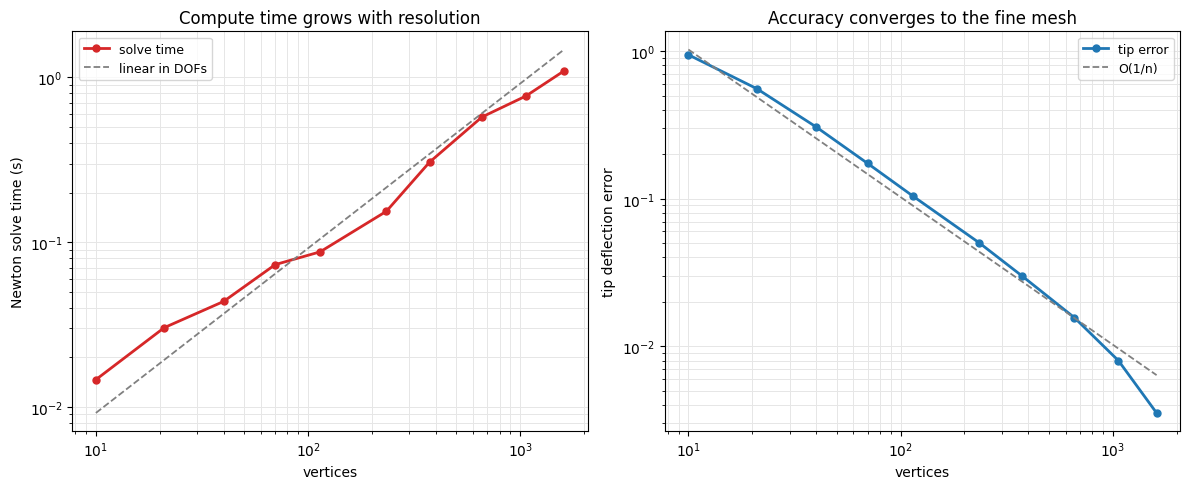

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
utils.loglog_plot(verts, {"solve time": times}, xlabel="vertices", ylabel="Newton solve time (s)",
    colors={"solve time": "#d62728"}, ref_slopes={"linear in DOFs": 1},
    title="Compute time grows with resolution", markers=True, ax=axes[0])
utils.loglog_plot(verts, {"tip error": errors}, xlabel="vertices", ylabel="tip deflection error",
    colors={"tip error": "#1f77b4"}, ref_slopes={"O(1/n)": -1},
    title="Accuracy converges to the fine mesh", markers=True, ax=axes[1])
fig.tight_layout(); plt.show()

## Watching three resolutions sag (clearly!) under gravity

Ramp gravity 0 &rarr; 1 and solve each frame for three resolutions, then **hold at
full gravity** so every beam settles to its final equilibrium and visibly comes to
rest. They converge to nearly the same big droop &mdash; but the finest one took far
longer per frame.


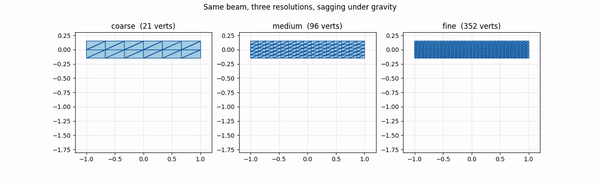

In [5]:
ramp = np.concatenate([np.linspace(0.0, 1.0, 22), np.ones(12)])   # ramp up, then hold at rest
panels = []
for nx, ny, label in [(7, 3, "coarse"), (16, 6, "medium"), (32, 11, "fine")]:
    states = [solve_beam(nx, ny, gravity_scale=g)["U"] for g in ramp]
    panels.append({"states": states, "T": solve_beam(nx, ny)["T"],
                   "title": f"{label}  ({states[0].shape[0]} verts)"})
fig, anim = utils.animate_meshes_grid(panels, lims=((-1.2, 1.2), (-1.8, 0.3)), fps=20,
    suptitle="Same beam, three resolutions, sagging under gravity")
utils.save_anim(anim, "media/10_resolution.mp4", fps=20)
plt.close(fig)
utils.show_anim(anim)

## Why "just refine it" is a trap

In [6]:
good = runs[4]                                            # a mid-resolution mesh
rel = abs(good["tip_y"] - reference["tip_y"]) / abs(reference["tip_y"])
print(f"good-enough ({good['n']:5d} verts): {good['time']*1000:8.1f} ms/solve   ({rel*100:.0f}% tip error)")
print(f"fine        ({reference['n']:5d} verts): {reference['time']*1000:8.1f} ms/solve")
print(f"\nThe fine mesh is ~{reference['time']/good['time']:.0f}x slower per solve for a tip deflection")
print(f"within {rel*100:.0f}% of it. Interactive editing (many solves/second) is impossible")
print("long before that accuracy is worth it -- pick the coarsest mesh that captures the behavior.")

good-enough (  114 verts):     87.3 ms/solve   (7% tip error)
fine        ( 2700 verts):   2221.7 ms/solve

The fine mesh is ~25x slower per solve for a tip deflection
within 7% of it. Interactive editing (many solves/second) is impossible
long before that accuracy is worth it -- pick the coarsest mesh that captures the behavior.


### Takeaways
* **Cost** rises steeply with vertex count; each Newton step solves a bigger
  sparse system.
* **Accuracy** improves with resolution but with diminishing returns.
* A super-fine mesh is accurate yet **too slow to iterate on**.

---
That completes the offline SimKit tutorial series (1&ndash;10): building and
understanding the deformation gradient, elastic energies, the elastostatic
minimization, the solvers and line search that drive it, time integration,
contact, and the resolution/cost trade-off.